# GC2D notebook demo

Este notebook ejecuta una simulacion corta usando la API reutilizable de `gc2d_core.gc2d_notebook`. 

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

In [2]:
%matplotlib inline
from typing import Any 
from gc2d_core.gc2d_dict import dict_list
from gc2d_core.gc2d_notebook import make_params, make_system, run_case
from gc2d_core.logging_config import configure_logging

configure_logging()

# Caso reducido para ejecucion interactiva rapida en notebook.
params: dict[str, Any] = make_params(
    dict_list[0],
    Tf=3,
    Tmid=1,
    Ntraj=12,
    M=6,
    TimeStep=0.1,
    TwoStepIntegration=False,
    PlotResults=False,
    SaveData=False,
    CheckEnergy=True,
)

system = make_system(params)

2026-07-01 13:00:13 | INFO     | MainProcess | gc2d_core.gc2d_notebook | Prepared notebook parameters: method=poincare_gc traj=gc A=0.7 rho=0.1 Ntraj=12 Tf=3 init=selected
2026-07-01 13:00:13 | INFO     | MainProcess | gc2d_core.gc2d_notebook | Building system: method=poincare_gc traj=gc A=0.7 rho=0.1 Ntraj=12 Tf=3
2026-07-01 13:00:13 | INFO     | MainProcess | gc2d_core.gc2d_symp | Initializing GC2Dt: traj=gc M=6 A=0.7 rho=0.1 eta=0.1 Ntraj=12 Tf=3
2026-07-01 13:00:13 | INFO     | MainProcess | gc2d_core.gc2d_symp | GC2Dt initialized with 22 active Fourier modes


In [3]:
_ = system.initial_conditions(type=system.init)

2026-07-01 13:00:16 | INFO     | MainProcess | gc2d_core.gc2d_symp | Generating initial conditions: type=selected traj=gc Ntraj=12
2026-07-01 13:00:16 | INFO     | MainProcess | gc2d_core.gc2d_symp | Using selected initial conditions with 12 trajectories
2026-07-01 13:00:16 | INFO     | MainProcess | gc2d_core.gc2d_symp | Initial condition vector ready: shape=(24,)


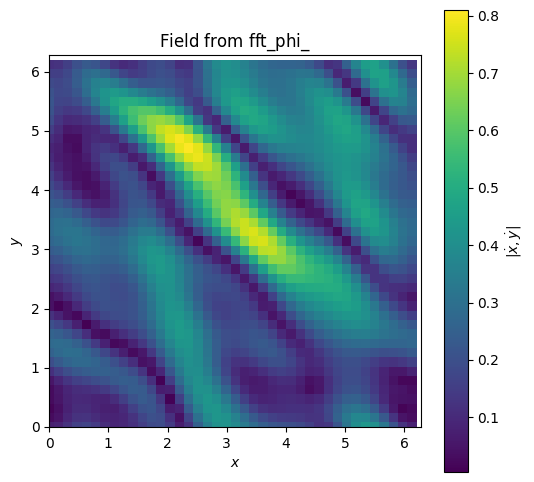

In [4]:
_ = system.plot_fft_phi(kind='magnitude')

In [5]:
result = run_case(system, plot=False)

2026-07-01 13:00:24 | INFO     | MainProcess | gc2d_core.gc2d_notebook | Running notebook case: plot=False
2026-07-01 13:00:24 | INFO     | MainProcess | gc2d_core.gc2d_symp | Generating initial conditions: type=selected traj=gc Ntraj=12
2026-07-01 13:00:24 | INFO     | MainProcess | gc2d_core.gc2d_symp | Using selected initial conditions with 12 trajectories
2026-07-01 13:00:24 | INFO     | MainProcess | gc2d_core.gc2d_symp | Initial condition vector ready: shape=(24,)
2026-07-01 13:00:24 | INFO     | MainProcess | gc2d_core.gc2d_notebook | Initial conditions ready: shape=(24,) init=selected
2026-07-01 13:00:24 | INFO     | MainProcess | gc2d_core.gc2d_notebook | Starting integration: method=poincare_gc traj=gc A=0.7 rho=0.1 Ntraj=12 Tf=3 solver=BM4 step=0.1 samples=4
2026-07-01 13:00:24 | INFO     | MainProcess | gc2d_core.gc2d_notebook | Using guiding-center integrator: solve_ivp_sympext
2026-07-01 13:00:24 | INFO     | MainProcess | gc2d_core.gc2d_notebook | solve_ivp_sympext param

In [6]:
result.get_trayectorys()

array([[[0.5       , 4.5       ],
        [0.48899077, 4.66993413],
        [0.4617989 , 4.89244374],
        [0.37853408, 5.183476  ]],

       [[0.51020408, 4.5       ],
        [0.49713358, 4.66709529],
        [0.4688687 , 4.88616586],
        [0.38705159, 5.17402976]],

       [[0.52040816, 4.5       ],
        [0.50529857, 4.66435843],
        [0.47591159, 4.88006815],
        [0.39541533, 5.16473949]],

       [[0.53061224, 4.5       ],
        [0.51348516, 4.66172807],
        [0.48292967, 4.87416253],
        [0.40362308, 5.15563219]],

       [[0.54081633, 4.5       ],
        [0.52169266, 4.65920788],
        [0.48992497, 4.86845916],
        [0.41167415, 5.14673222]],

       [[0.55102041, 4.5       ],
        [0.52992039, 4.65680073],
        [0.49689948, 4.8629665 ],
        [0.41956915, 5.1380613 ]],

       [[0.56122449, 4.5       ],
        [0.53816757, 4.65450874],
        [0.50385504, 4.85769144],
        [0.42730985, 5.12963853]],

       [[0.57142857, 4.5       ],


In [7]:
result.get_initials_conditions()

array([[0.5       , 4.5       ],
       [0.51020408, 4.5       ],
       [0.52040816, 4.5       ],
       [0.53061224, 4.5       ],
       [0.54081633, 4.5       ],
       [0.55102041, 4.5       ],
       [0.56122449, 4.5       ],
       [0.57142857, 4.5       ],
       [0.58163265, 4.5       ],
       [0.59183673, 4.5       ],
       [0.60204082, 4.5       ],
       [0.6122449 , 4.5       ]])

2026-06-29 18:15:44 | INFO     | MainProcess | gc2d_core.gc2d_notebook | Plotting Poincare section: traj=gc modulo=True


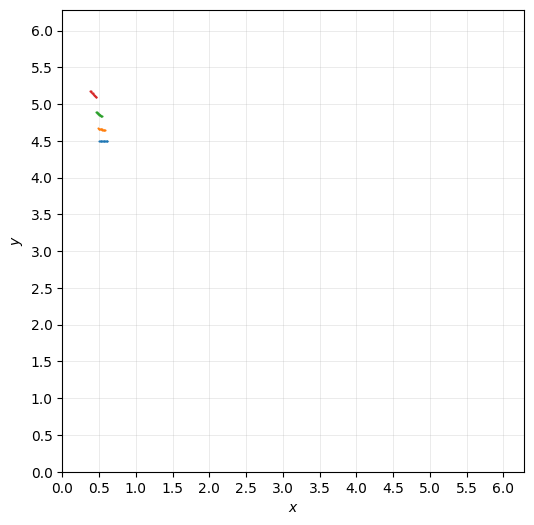

In [8]:
_ = result.plot_poincare(decimal_grid = True)